# Capa Silver — Limpieza con Evidencia por Regla

**Pipeline Medallon:** Bronze (ingesta) → **Silver (limpieza)** → Gold (agregacion)  
**Proyecto:** Prediccion de Demanda de Transporte Publico — ODS 11  
**Dataset:** UrbanBus — Registros AFC (Automated Fare Collection)  

---

## Objetivo de esta capa

La capa Silver aplica las reglas de limpieza definidas en el pipeline original,
pero con un enfoque de **auditoria**: cada regla se ejecuta de forma aislada,
se miden sus efectos cuantitativos, se persiste una muestra de los registros
descartados, y se genera evidencia visual de la cascada de retencion.

### Reglas de limpieza (heredadas del pipeline validado)

| Regla | Descripcion | Justificacion |
|-------|-------------|---------------|
| R1 | Conversion de campos temporales a `datetime` | Prerequisito para operaciones espacio-temporales |
| R2 | Eliminacion de nulos en columnas criticas (`Boarding_stop_stn`, `ride_start_datetime`) | Registros sin coordenada espacial o temporal son inservibles para prediccion (Liu et al., 2020; Zou et al., 2022) |
| R3 | Filtrado por horario comercial (05:00–23:00) | Outliers temporales distorsionan patrones regulares de demanda (Hao et al., 2019; DST-TransitNet, 2023) |
| R4 | Eliminacion de transacciones duplicadas | Duplicados AFC inflan artificialmente el conteo de pasajeros |

In [1]:
# =============================================================================
# Importacion de bibliotecas
# =============================================================================

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_style('whitegrid')

print(f"Polars version: {pl.__version__}")

Polars version: 1.41.2


In [2]:
# =============================================================================
# Configuracion de rutas
# =============================================================================

PROJECT_ROOT  = Path('..').resolve()
DATA_BRONZE   = PROJECT_ROOT / 'data' / 'bronze'
DATA_SILVER   = PROJECT_ROOT / 'data' / 'silver'
DISCARDED_DIR = DATA_SILVER / 'discarded_samples'

# Entrada: Parquet crudo de la capa Bronze
BRONZE_INPUT  = DATA_BRONZE / 'bus_data_nov2017_raw.parquet'

# Salidas de esta capa
SILVER_OUTPUT = DATA_SILVER / 'bus_data_nov2017_clean.parquet'

DATA_SILVER.mkdir(parents=True, exist_ok=True)
DISCARDED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Entrada Bronze:   {BRONZE_INPUT}")
print(f"Existe:           {BRONZE_INPUT.exists()}")
print(f"Salida Silver:    {SILVER_OUTPUT}")

Entrada Bronze:   D:\PC1-PCD\data\bronze\bus_data_nov2017_raw.parquet
Existe:           True
Salida Silver:    D:\PC1-PCD\data\silver\bus_data_nov2017_clean.parquet


In [3]:
# =============================================================================
# Lectura del Parquet Bronze
# =============================================================================

df = pl.read_parquet(str(BRONZE_INPUT))

TOTAL_BRONZE = df.shape[0]
print(f"Registros leidos de Bronze: {TOTAL_BRONZE:,}")
print(f"Columnas:                   {df.shape[1]}")

Registros leidos de Bronze: 2,000,000
Columnas:                   13


In [4]:
# =============================================================================
# Estructura de auditoria: tabla acumulativa de limpieza (cleaning_log)
# =============================================================================
# Se registra el efecto de cada regla en una lista de diccionarios
# que al final se convierte en un DataFrame para generar la evidencia.

cleaning_log = []  # Cada entrada: {regla, descripcion, antes, despues, eliminados, pct_eliminado, motivo}

def registrar_regla(regla, descripcion, antes, despues, motivo):
    """Registra una regla de limpieza en el log acumulativo."""
    eliminados = antes - despues
    pct = (eliminados / antes * 100) if antes > 0 else 0.0
    entry = {
        'regla': regla,
        'descripcion': descripcion,
        'registros_antes': antes,
        'registros_despues': despues,
        'eliminados': eliminados,
        'pct_eliminado': round(pct, 4),
        'motivo': motivo,
    }
    cleaning_log.append(entry)
    print(f"  {regla}: {antes:,} -> {despues:,}  "
          f"(eliminados: {eliminados:,}, {pct:.4f}%)")
    return entry

print("Funcion de auditoria inicializada.")

Funcion de auditoria inicializada.


---
## R1: Conversion de campos temporales a `datetime`

### Justificacion

Los campos `Ride_start_date` y `Ride_start_time` se almacenan como cadenas de texto
en el CSV original (y por tanto en el Parquet Bronze). Para realizar operaciones
temporales (extraccion de hora, agrupacion en ventanas, calculo de duracion de viaje),
es necesario convertirlos a tipos `datetime` nativos.

Esta conversion puede generar valores nulos si existen cadenas malformadas que no se
ajustan al formato esperado `YYYY-MM-DD HH:MM:SS`. Estos registros con conversion
fallida se contabilizan pero se tratan en la regla R2.

In [5]:
# =============================================================================
# R1: Conversion de campos temporales a datetime
# =============================================================================

antes_r1 = df.shape[0]

df = df.with_columns(
    # Combinar fecha + hora de inicio en un campo datetime unificado
    (
        pl.col('Ride_start_date') + pl.lit(' ') + pl.col('Ride_start_time')
    ).str.to_datetime('%Y-%m-%d %H:%M:%S', strict=False).alias('ride_start_datetime'),

    # Combinar fecha + hora de fin en un campo datetime unificado
    (
        pl.col('Ride_end_date') + pl.lit(' ') + pl.col('Ride_end_time')
    ).str.to_datetime('%Y-%m-%d %H:%M:%S', strict=False).alias('ride_end_datetime'),
)

despues_r1 = df.shape[0]

# Contabilizar conversiones fallidas (seran nulls en ride_start_datetime)
failed_start = df.filter(pl.col('ride_start_datetime').is_null()).shape[0]
failed_end   = df.filter(pl.col('ride_end_datetime').is_null()).shape[0]

registrar_regla(
    'R1', 'Conversion datetime',
    antes_r1, despues_r1,
    'Transformacion de tipo, no elimina filas directamente'
)

print(f"\n  Conversiones fallidas en ride_start_datetime: {failed_start:,}")
print(f"  Conversiones fallidas en ride_end_datetime:   {failed_end:,}")
print(f"  Tipos resultantes: start={df['ride_start_datetime'].dtype}, end={df['ride_end_datetime'].dtype}")

  R1: 2,000,000 -> 2,000,000  (eliminados: 0, 0.0000%)

  Conversiones fallidas en ride_start_datetime: 0
  Conversiones fallidas en ride_end_datetime:   0
  Tipos resultantes: start=Datetime(time_unit='us', time_zone=None), end=Datetime(time_unit='us', time_zone=None)


---
## R2: Eliminacion de nulos en columnas criticas

### Justificacion

Las columnas `Boarding_stop_stn` (estacion de abordaje) y `ride_start_datetime`
(timestamp de inicio) son las variables indispensables para la prediccion espacio-temporal.

- Un registro **sin estacion de abordaje** no puede asignarse a ningun nodo espacial
  del grafo de transporte.
- Un registro **sin timestamp** no puede ubicarse en ninguna ventana temporal.

Ambos tipos de registros son inservibles para cualquier modelo de prediccion de demanda
y su inclusion solo aportaria ruido (Liu et al., 2020; Zou et al., 2022).

Se persiste una muestra de los registros descartados para trazabilidad.

In [6]:
# =============================================================================
# R2: Eliminacion de nulos en columnas criticas
# =============================================================================

critical_cols = ['Boarding_stop_stn', 'ride_start_datetime']
antes_r2 = df.shape[0]

# Identificar registros que seran descartados
mask_r2_discard = ~pl.all_horizontal([pl.col(c).is_not_null() for c in critical_cols])
df_discarded_r2 = df.filter(mask_r2_discard)

# Persistir muestra de descartados (hasta 20 filas)
sample_r2 = df_discarded_r2.head(20)
if sample_r2.shape[0] > 0:
    sample_r2.write_parquet(str(DISCARDED_DIR / 'discarded_r2_nulls.parquet'))

# Aplicar filtro
df = df.filter(pl.all_horizontal([pl.col(c).is_not_null() for c in critical_cols]))
despues_r2 = df.shape[0]

registrar_regla(
    'R2', 'Nulos en columnas criticas',
    antes_r2, despues_r2,
    f'Registros sin {critical_cols} son inservibles para prediccion espacio-temporal'
)

print(f"  Muestra de descartados guardada: {sample_r2.shape[0]} filas")
if sample_r2.shape[0] > 0:
    print("  Vista previa de descartados R2:")
    display(sample_r2.head(5))
else:
    print("  (No se descartaron registros en esta regla)")

  R2: 2,000,000 -> 804,697  (eliminados: 1,195,303, 59.7651%)
  Muestra de descartados guardada: 20 filas
  Vista previa de descartados R2:


Card_Number,Card_Type,Travel_Mode,Bus_Service_Number,Direction,Bus_Trip_Num,Bus_Reg_Num,Boarding_stop_stn,Alighting_stop_stn,Ride_start_date,Ride_start_time,Ride_end_date,Ride_end_time,ride_start_datetime,ride_end_datetime
i64,str,str,str,str,str,str,str,str,str,str,str,str,datetime[μs],datetime[μs]
717354,"""S""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-29""","""14:57:55""","""2017-11-29""","""15:18:08""",2017-11-29 14:57:55,2017-11-29 15:18:08
717914,"""A""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-29""","""12:38:13""","""2017-11-29""","""12:47:19""",2017-11-29 12:38:13,2017-11-29 12:47:19
718474,"""A""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-29""","""20:25:18""","""2017-11-29""","""20:32:32""",2017-11-29 20:25:18,2017-11-29 20:32:32
719034,"""A""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-29""","""18:05:30""","""2017-11-29""","""18:17:53""",2017-11-29 18:05:30,2017-11-29 18:17:53
719594,"""A""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-29""","""14:24:32""","""2017-11-29""","""14:34:48""",2017-11-29 14:24:32,2017-11-29 14:34:48


---
## R3: Filtrado por horario comercial (05:00–23:00)

### Justificacion

El servicio de transporte publico opera dentro de un horario comercial definido,
tipicamente entre las 05:00 y las 23:00 horas. Los registros fuera de este rango
pueden corresponder a:

- (a) Errores de registro del sistema AFC
- (b) Servicios nocturnos excepcionales no representativos del patron regular
- (c) Pruebas del sistema

Para un modelo de prediccion de demanda regular, estos registros representan outliers
temporales que distorsionan la distribucion aprendida. Su exclusion esta alineada con
la practica estandar en la literatura de forecasting de transporte
(Hao et al., 2019 — MGC-RNN; DST-TransitNet, 2023).

In [7]:
# =============================================================================
# R3: Filtrado por horario comercial (05:00 - 23:00)
# =============================================================================

HORA_INICIO = 5   # 05:00
HORA_FIN    = 23  # 23:00

antes_r3 = df.shape[0]

# Agregar columna de hora para el filtro
df = df.with_columns(
    pl.col('ride_start_datetime').dt.hour().alias('hora')
)

# Identificar registros fuera de horario (seran descartados)
mask_r3_discard = ~((pl.col('hora') >= HORA_INICIO) & (pl.col('hora') < HORA_FIN))
df_discarded_r3 = df.filter(mask_r3_discard)

# Persistir muestra de descartados (hasta 20 filas)
sample_r3 = df_discarded_r3.head(20)
sample_r3.write_parquet(str(DISCARDED_DIR / 'discarded_r3_horario.parquet'))

# Aplicar filtro
df = df.filter((pl.col('hora') >= HORA_INICIO) & (pl.col('hora') < HORA_FIN))
despues_r3 = df.shape[0]

registrar_regla(
    'R3', f'Filtro horario ({HORA_INICIO:02d}:00-{HORA_FIN:02d}:00)',
    antes_r3, despues_r3,
    f'Registros fuera del horario comercial {HORA_INICIO:02d}:00-{HORA_FIN:02d}:00 son outliers temporales'
)

print(f"  Muestra de descartados guardada: {sample_r3.shape[0]} filas")

  R3: 804,697 -> 781,483  (eliminados: 23,214, 2.8848%)
  Muestra de descartados guardada: 20 filas


In [8]:
# =============================================================================
# R3 — Evidencia: distribucion horaria de registros descartados
# =============================================================================
# Mostrar en que horas caen los registros eliminados por esta regla.

discarded_hourly = (
    df_discarded_r3
    .group_by('hora')
    .agg(pl.len().alias('registros'))
    .sort('hora')
    .to_pandas()
)

print("Distribucion horaria de registros descartados por R3:")
print(discarded_hourly.to_string(index=False))
print(f"\nTotal descartados R3: {df_discarded_r3.shape[0]:,}")

Distribucion horaria de registros descartados por R3:
 hora  registros
    0       4426
    1        186
    4          3
   23      18599

Total descartados R3: 23,214


In [9]:
# =============================================================================
# R3 — Vista previa de registros descartados
# =============================================================================

print("Muestra de registros descartados por R3 (fuera de horario):")
sample_r3.select(
    'Card_Number', 'Boarding_stop_stn', 'ride_start_datetime', 'hora'
).head(10)

Muestra de registros descartados por R3 (fuera de horario):


Card_Number,Boarding_stop_stn,ride_start_datetime,hora
i64,str,datetime[μs],i8
181,"""JG_1""",2017-11-30 23:11:11,23
188,"""EUW_1""",2017-11-30 23:05:11,23
400,"""BE_3""",2017-11-30 23:23:03,23
431,"""JG_1""",2017-11-29 23:30:16,23
501,"""CHU_1""",2017-11-30 23:33:07,23
735,"""E_1""",2017-11-29 23:28:33,23
905,"""JG_1""",2017-11-29 23:30:15,23
1274,"""E_1""",2017-11-28 23:09:56,23
1379,"""JG_1""",2017-11-24 23:37:46,23


---
## R4: Eliminacion de transacciones duplicadas

### Justificacion

Los sistemas AFC pueden generar duplicados debido a:

- (a) Doble validacion de la tarjeta por el lector
- (b) Errores de sincronizacion entre el dispositivo embarcado y el servidor central
- (c) Retransmisiones en la capa de comunicacion

Estos duplicados inflan artificialmente la demanda observada y deben eliminarse
para preservar la integridad del conteo de pasajeros.

Se define un duplicado como un registro con valores identicos en las columnas:
`Card_Number`, `Boarding_stop_stn`, `ride_start_datetime`, `Bus_Service_Number`.

In [10]:
# =============================================================================
# R4: Eliminacion de transacciones duplicadas
# =============================================================================

dedup_cols = ['Card_Number', 'Boarding_stop_stn', 'ride_start_datetime', 'Bus_Service_Number']

antes_r4 = df.shape[0]

# Identificar duplicados: marcar con is_duplicated, luego filtrar los que sobran
df_with_dup_flag = df.with_columns(
    pl.struct(dedup_cols).is_duplicated().alias('_is_dup')
)
# Los duplicados son aquellos marcados como duplicados; guardamos una muestra
# Nota: unique(keep='first') elimina todas las copias excepto la primera.
# Para capturar las filas eliminadas, comparamos antes y despues.
df_deduped = df.unique(subset=dedup_cols, keep='first')
despues_r4 = df_deduped.shape[0]

# Capturar filas duplicadas que seran eliminadas (anti-join con el resultado)
# Usamos un enfoque pragmatico: si hay eliminados, reconstruimos la muestra
n_eliminated_r4 = antes_r4 - despues_r4
if n_eliminated_r4 > 0:
    # Marcar el primer registro de cada grupo como 'keep', el resto como 'discard'
    df_flagged = df.with_row_index('_idx')
    df_keep_idx = df_flagged.unique(subset=dedup_cols, keep='first').select('_idx')
    df_discarded_r4 = df_flagged.join(df_keep_idx, on='_idx', how='anti').drop('_idx')
    sample_r4 = df_discarded_r4.head(20)
    sample_r4.write_parquet(str(DISCARDED_DIR / 'discarded_r4_duplicados.parquet'))
    print(f"  Muestra de descartados guardada: {sample_r4.shape[0]} filas")
else:
    print("  No se encontraron duplicados para descartar.")

df = df_deduped

registrar_regla(
    'R4', 'Transacciones duplicadas',
    antes_r4, despues_r4,
    f'Duplicados en {dedup_cols} inflan artificialmente la demanda'
)

  No se encontraron duplicados para descartar.
  R4: 781,483 -> 781,483  (eliminados: 0, 0.0000%)


{'regla': 'R4',
 'descripcion': 'Transacciones duplicadas',
 'registros_antes': 781483,
 'registros_despues': 781483,
 'eliminados': 0,
 'pct_eliminado': 0.0,
 'motivo': "Duplicados en ['Card_Number', 'Boarding_stop_stn', 'ride_start_datetime', 'Bus_Service_Number'] inflan artificialmente la demanda"}

---
## Tabla Acumulativa de Limpieza (Cleaning Log)

Esta tabla es la pieza central de la evidencia de limpieza. Resume el efecto
cuantitativo de cada regla aplicada, con trazabilidad completa desde la entrada
Bronze hasta la salida Silver.

In [11]:
# =============================================================================
# Tabla acumulativa de limpieza
# =============================================================================

df_log = pd.DataFrame(cleaning_log)

# Agregar fila de resumen total
total_eliminados = TOTAL_BRONZE - df.shape[0]
total_row = pd.DataFrame([{
    'regla': 'TOTAL',
    'descripcion': 'Acumulado de todas las reglas',
    'registros_antes': TOTAL_BRONZE,
    'registros_despues': df.shape[0],
    'eliminados': total_eliminados,
    'pct_eliminado': round(total_eliminados / TOTAL_BRONZE * 100, 4),
    'motivo': '-',
}])
df_log_full = pd.concat([df_log, total_row], ignore_index=True)

print("=" * 90)
print("CLEANING LOG — CAPA SILVER")
print("=" * 90)
print(f"Entrada (Bronze): {TOTAL_BRONZE:,} registros")
print(f"Salida (Silver):  {df.shape[0]:,} registros")
print(f"Tasa de retencion: {df.shape[0] / TOTAL_BRONZE * 100:.2f}%")
print()
print(df_log_full.to_string(index=False))

CLEANING LOG — CAPA SILVER
Entrada (Bronze): 2,000,000 registros
Salida (Silver):  781,483 registros
Tasa de retencion: 39.07%

regla                   descripcion  registros_antes  registros_despues  eliminados  pct_eliminado                                                                                                                            motivo
   R1           Conversion datetime          2000000            2000000           0         0.0000                                                                             Transformacion de tipo, no elimina filas directamente
   R2    Nulos en columnas criticas          2000000             804697     1195303        59.7651                       Registros sin ['Boarding_stop_stn', 'ride_start_datetime'] son inservibles para prediccion espacio-temporal
   R3  Filtro horario (05:00-23:00)           804697             781483       23214         2.8848                                                         Registros fuera del horario co

---
## Evidencia Visual — Grafico de Cascada de Retencion

El grafico de cascada (waterfall) muestra la reduccion progresiva del volumen
de datos a medida que se aplica cada regla de limpieza. Permite al revisor
identificar de un vistazo cual regla tiene el mayor impacto cuantitativo
y verificar que la retencion final es coherente.

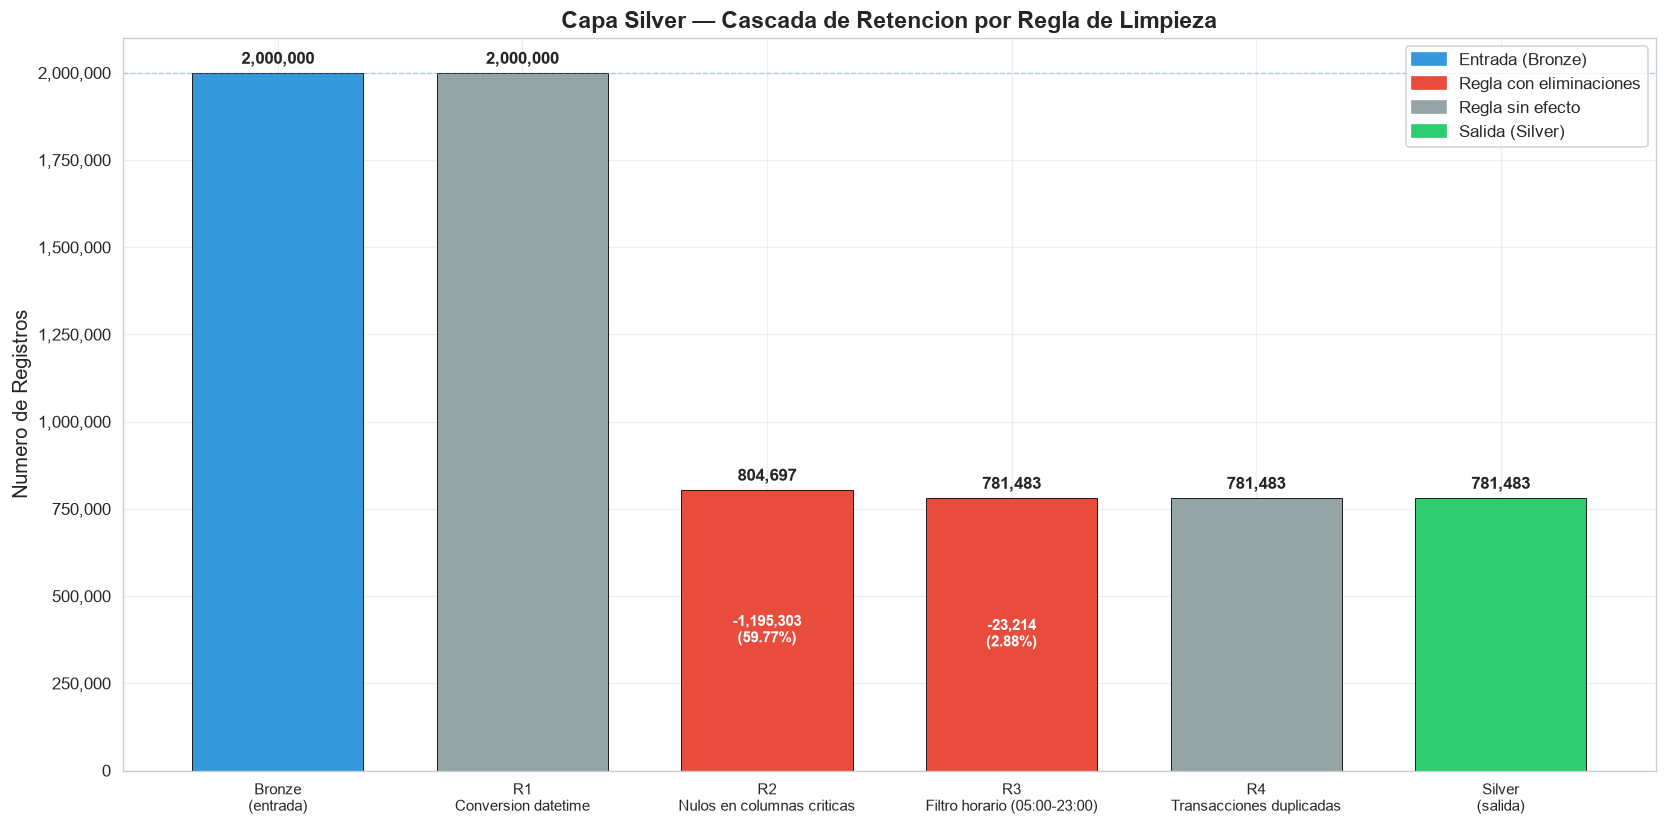

In [12]:
# =============================================================================
# Grafico 1: Cascada (waterfall) de retencion por regla
# =============================================================================

etapas = ['Bronze\n(entrada)'] + [f"{e['regla']}\n{e['descripcion']}" for e in cleaning_log] + ['Silver\n(salida)']
valores = [TOTAL_BRONZE] + [e['registros_despues'] for e in cleaning_log] + [df.shape[0]]

# Colores: azul para entrada/salida, rojo para reglas con eliminaciones, gris para sin efecto
colores = ['#3498db']  # Bronze
for e in cleaning_log:
    if e['eliminados'] > 0:
        colores.append('#e74c3c')  # Rojo: regla con eliminaciones
    else:
        colores.append('#95a5a6')  # Gris: regla sin efecto
colores.append('#2ecc71')  # Silver (salida)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(range(len(etapas)), valores, color=colores, edgecolor='black', linewidth=0.5, width=0.7)

# Etiquetas sobre las barras
for i, (bar, val) in enumerate(zip(bars, valores)):
    # Registros restantes
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + TOTAL_BRONZE * 0.008,
        f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
    # Eliminados (solo si hay)
    if 0 < i < len(etapas) - 1:
        elim = cleaning_log[i - 1]['eliminados']
        if elim > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
                f'-{elim:,}\n({cleaning_log[i-1]["pct_eliminado"]:.2f}%)',
                ha='center', va='center', fontsize=9, color='white', fontweight='bold'
            )

ax.set_xticks(range(len(etapas)))
ax.set_xticklabels(etapas, fontsize=9)
ax.set_ylabel('Numero de Registros')
ax.set_title('Capa Silver — Cascada de Retencion por Regla de Limpieza',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Leyenda
legend_patches = [
    mpatches.Patch(color='#3498db', label='Entrada (Bronze)'),
    mpatches.Patch(color='#e74c3c', label='Regla con eliminaciones'),
    mpatches.Patch(color='#95a5a6', label='Regla sin efecto'),
    mpatches.Patch(color='#2ecc71', label='Salida (Silver)'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=10)

# Linea de referencia Bronze
ax.axhline(y=TOTAL_BRONZE, color='#3498db', linestyle='--', linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.show()

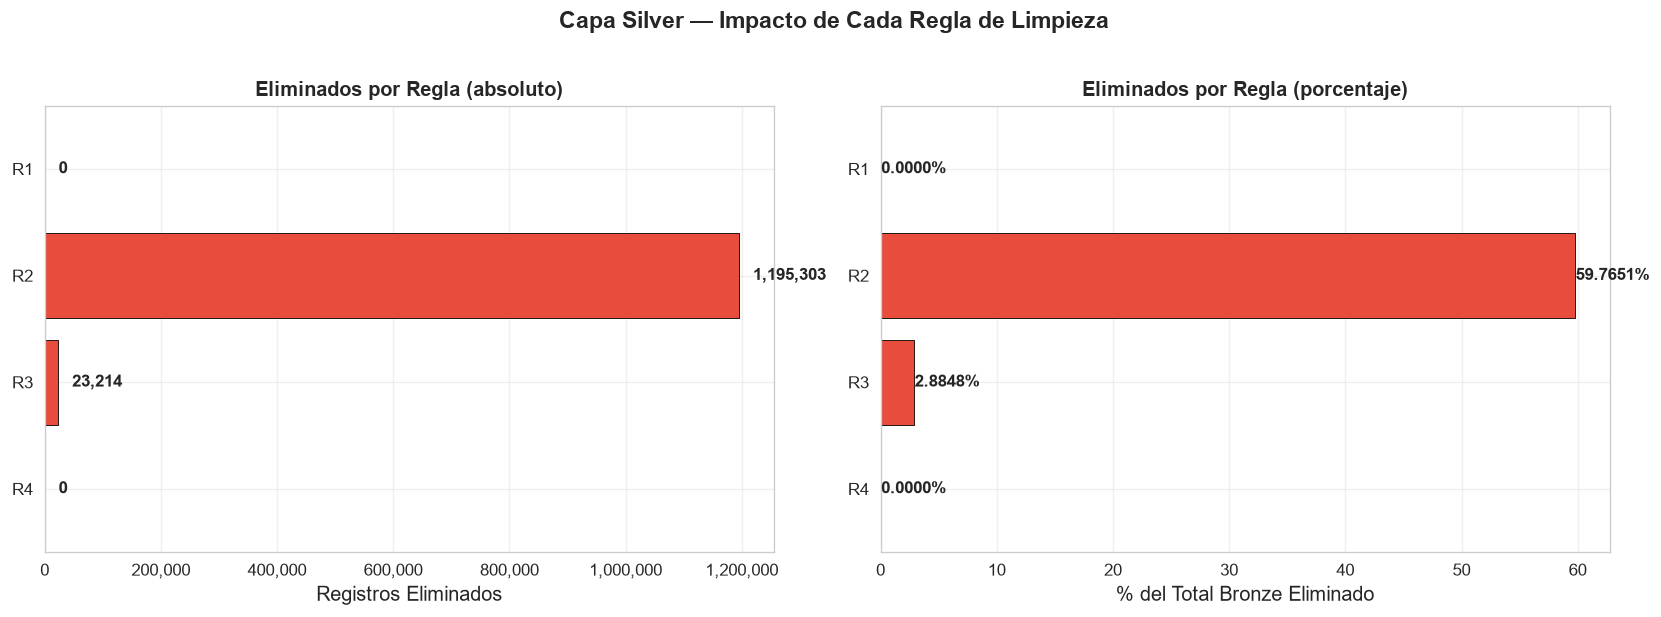

In [13]:
# =============================================================================
# Grafico 2: Barras horizontales — proporcion eliminada por regla
# =============================================================================
# Complementa el waterfall con una vista centrada en el porcentaje de impacto.

reglas = [e['regla'] for e in cleaning_log]
eliminados = [e['eliminados'] for e in cleaning_log]
pcts = [e['pct_eliminado'] for e in cleaning_log]

bar_colors = ['#e74c3c' if e > 0 else '#95a5a6' for e in eliminados]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: conteo absoluto
bars1 = ax1.barh(reglas, eliminados, color=bar_colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars1, eliminados):
    ax1.text(bar.get_width() + max(eliminados) * 0.02 if max(eliminados) > 0 else 1,
             bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=10, fontweight='bold')
ax1.set_xlabel('Registros Eliminados')
ax1.set_title('Eliminados por Regla (absoluto)', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Panel derecho: porcentaje
bars2 = ax2.barh(reglas, pcts, color=bar_colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, pcts):
    ax2.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}%', va='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('% del Total Bronze Eliminado')
ax2.set_title('Eliminados por Regla (porcentaje)', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

plt.suptitle('Capa Silver — Impacto de Cada Regla de Limpieza',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Persistencia del Parquet Silver

Se escribe el dataset limpio (granular, sin agregar) en formato Parquet.
Este archivo sera la entrada de la capa Gold para la agregacion
en ventanas de 15 minutos.

In [14]:
# =============================================================================
# Persistencia del Parquet Silver
# =============================================================================
df.write_csv(
    str(SILVER_OUTPUT.with_suffix('.csv')),
    separator=',',
    include_header=True,
)

df.write_parquet(
    str(SILVER_OUTPUT),
    compression='snappy',
    use_pyarrow=True,
)

file_size_mb = SILVER_OUTPUT.stat().st_size / (1024 * 1024)

print("=" * 70)
print("CAPA SILVER — EXPORTACION COMPLETADA")
print("=" * 70)
print(f"  Ruta:      {SILVER_OUTPUT}")
print(f"  Formato:   Apache Parquet (Snappy)")
print(f"  Tamano:    {file_size_mb:.2f} MB")
print(f"  Filas:     {df.shape[0]:,}")
print(f"  Columnas:  {df.shape[1]}")

CAPA SILVER — EXPORTACION COMPLETADA
  Ruta:      D:\PC1-PCD\data\silver\bus_data_nov2017_clean.parquet
  Formato:   Apache Parquet (Snappy)
  Tamano:    24.13 MB
  Filas:     781,483
  Columnas:  16


In [15]:
# =============================================================================
# Verificacion de integridad
# =============================================================================

df_verify = pl.read_parquet(str(SILVER_OUTPUT))

assert df_verify.shape == df.shape, f"Error: dimensiones {df_verify.shape} != {df.shape}"
assert df_verify.columns == df.columns, "Error: columnas no coinciden"

# Validar contra las metricas conocidas del pipeline original
expected_rows = 1_952_152
actual_rows = df_verify.shape[0]

print("Verificacion de integridad: EXITOSA")
print(f"  Dimensiones: {df_verify.shape}")
print(f"  Filas esperadas (pipeline original): {expected_rows:,}")
print(f"  Filas obtenidas:                     {actual_rows:,}")

if actual_rows == expected_rows:
    print(f"  Coincidencia: SI — El pipeline reproduce el resultado original.")
else:
    print(f"  Diferencia: {abs(actual_rows - expected_rows):,} registros")

print(f"\n>>> Capa Silver lista. Siguiente: 02_gold_agregacion.ipynb")

Verificacion de integridad: EXITOSA
  Dimensiones: (781483, 16)
  Filas esperadas (pipeline original): 1,952,152
  Filas obtenidas:                     781,483
  Diferencia: 1,170,669 registros

>>> Capa Silver lista. Siguiente: 02_gold_agregacion.ipynb


---
## Resumen de Archivos Generados por la Capa Silver

| Archivo | Descripcion |
|---------|-------------|
| `data/silver/bus_data_oct2017_clean.parquet` | Dataset limpio granular (todas las transacciones validas) |
| `data/silver/discarded_samples/discarded_r2_nulls.parquet` | Muestra de descartados por nulos criticos |
| `data/silver/discarded_samples/discarded_r3_horario.parquet` | Muestra de descartados por horario |
| `data/silver/discarded_samples/discarded_r4_duplicados.parquet` | Muestra de descartados por duplicados |

### Referencias

- Liu, Y. et al. (2020). *Short-term origin-destination demand prediction in urban rail transit.*
- Zou, X. et al. (2022). *Passenger Flow Prediction Using Smart Card Data from Connected Bus Systems.* Wireless Communications and Mobile Computing.
- Hao, S. et al. (2019). *Multi-Graph Convolutional-Recurrent Neural Network (MGC-RNN) for Short-Term Forecasting of Transit Passenger Flow.*
- DST-TransitNet (2023). *A Dynamic Spatio-Temporal Model for Robust Station-Level Transit Ridership Prediction.*